1. DATA

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
import warnings

2. Log path loss model

In [ ]:
import numpy as np
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error

# Do it here for the small
df = pd.read_csv("outputs/tests_gh_25_06/clean_data.csv")

# Gateway assumed at origin (0, 0) on the walking path
df['distance'] = np.sqrt(df['x_m']**2 + df['y_m']**2)

# Row crossings: physical rows between sensor and path.
# there is 1.6 m between each row CHECK THIS!!!!
df['row_crossings'] = (df['y_m'].abs() / 1.1).round().astype(int)

# Grid label needed downstream (Moran's I aggregation, grouped CV, GPR)
df['grid_label'] = df['structure_id'] + '_G' + df['manual_group'].astype(str)

print('Row crossings by y_m:')
print(df.groupby('y_m')['row_crossings'].first())

valid = df.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

log_d = np.log10(valid['distance'].values)
rssi = valid['rssi'].values
crossings = valid['row_crossings'].values

# --- Model 1: baseline, no row_crossings ---
X_pl_base = np.column_stack([np.ones(len(valid)), log_d])
coeffs_base, _, _, _ = lstsq(X_pl_base, rssi, rcond=None)
A_g_base, n_log10_base = coeffs_base
pred_base = X_pl_base @ coeffs_base
rmse_base = np.sqrt(mean_squared_error(rssi, pred_base))

# --- Model 2: with row_crossings (currently the retained/reported model) ---
X_pl_full = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_full, _, _, _ = lstsq(X_pl_full, rssi, rcond=None)
A_g_full, n_log10_full, beta = coeffs_full
pred_full = X_pl_full @ coeffs_full
rmse_full = np.sqrt(mean_squared_error(rssi, pred_full))

# Store pl_pred / pl_residual on valid using the FULL model — these are
# consumed downstream by Moran's I and GPR input prep
valid['pl_pred'] = pred_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

print('\n=== Path-Loss Model Comparison ===')
print('Baseline (no row_crossings):')
print(f'  A_g (intercept)     : {A_g_base:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_base/10:.3f}')
print(f'  RMSE                : {rmse_base:.2f} dBm')
print()
print('With row_crossings term:')
print(f'  A_g (intercept)     : {A_g_full:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_full/10:.3f}')
print(f'  β   (row penalty)   : {beta:.2f} dBm per row crossed')
print(f'  RMSE                : {rmse_full:.2f} dBm')
print()
print(f'RMSE improvement: {rmse_base - rmse_full:.3f} dBm')

# Multicollinearity sanity check between log_d and crossings
corr = np.corrcoef(log_d, crossings)[0, 1]
print(f'\nCorrelation(log10(distance), row_crossings): {corr:.3f}')
print('(if this is very high, β may still be poorly estimated despite')
print(' technically being identifiable)')

Row crossings by y_m:
y_m
-21.3      19
-16.9      15
-12.5      11
-12.1      11
-8.1        7
-5.5        5
-3.7        3
-1.5        1
 5.5        5
 9.5        9
 17.6      16
 18.3      17
 27.1      25
 29.7      27
 39.6      36
 49.1      45
 50.6      46
 65.6      60
 75.5      69
 83.6      76
 89.8      82
 94.6      86
 98.6      90
 105.6     96
 109.6    100
Name: row_crossings, dtype: int64

=== Path-Loss Model Comparison ===
Baseline (no row_crossings):
  A_g (intercept)     : -28.34 dBm
  n   (path-loss exp) : 3.542
  RMSE                : 6.45 dBm

With row_crossings term:
  A_g (intercept)     : -29.27 dBm
  n   (path-loss exp) : 3.412
  β   (row penalty)   : -0.05 dBm per row crossed
  RMSE                : 6.30 dBm

RMSE improvement: 0.147 dBm

Correlation(log10(distance), row_crossings): 0.276
(if this is very high, β may still be poorly estimated despite
 technically being identifiable)


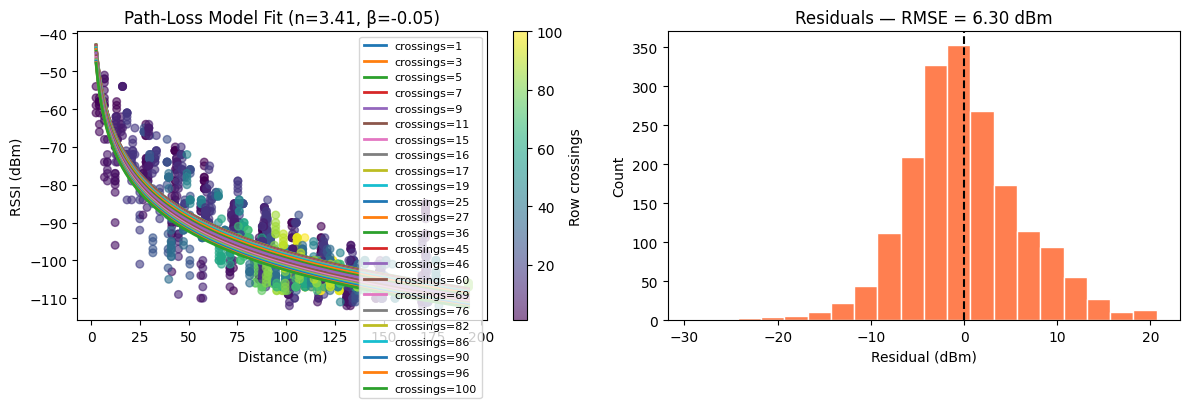

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute pl_pred / pl_residual on valid using the FULL model
valid['pl_pred'] = X_pl_full @ coeffs_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

# Scatter colored by row_crossings so the plot reflects that pl_pred
# now depends on crossings too, not just distance
scatter = axes[0].scatter(
    valid['distance'], valid['rssi'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

# Plot fit lines for each observed crossing level, holding it fixed per line
for c in sorted(valid['row_crossings'].unique()):
    pl_line = A_g_full + n_log10_full * np.log10(d_range) + beta * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_title(f'Path-Loss Model Fit (n={-n_log10_full/10:.2f}, β={beta:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['pl_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals — RMSE = {rmse_full:.2f} dBm')

plt.tight_layout()
plt.savefig('pathloss_fit.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I. 

Running Moran's I on 258 grid cell medians (not 1849 individual packets)
=== Moran's I Test ===
  Moran's I : 0.4029
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: proceed to GPR residual model.


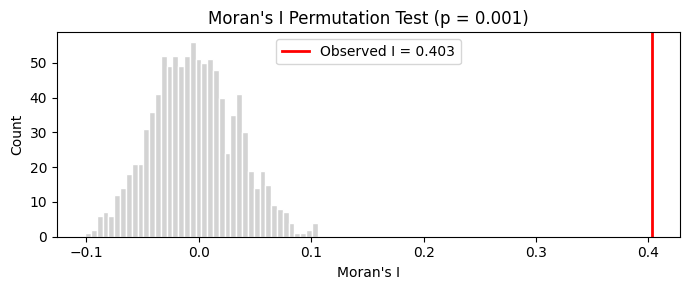

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran

# Aggregate to one mean residual per grid cell before testing.
# Repeated packets at the same location are not independent spatial
# units — using them directly would inflate the effective N and bias
# the test (same pseudo-replication issue as the OLS/row_crossings check).
cell_medians = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('pl_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('pl_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians)} grid cell medians (not {len(valid)} individual packets)")

coords_arr = cell_medians[['x_m', 'y_m']].values
residuals_arr = cell_medians['median_residual'].values

# k-NN spatial weights: each cell's "neighbors" are its k nearest cells
k = min(5, len(cell_medians) - 1)  # lower this, or switch to a distance-band
                                   # weight matrix, if results are borderline
w = KNN.from_array(coords_arr, k=k)
w.transform = 'r'   # row-standardize weights (esda's Moran expects this)

np.random.seed(42)
moran = Moran(residuals_arr, w, permutations=999)

print("=== Moran's I Test ===")
print(f"  Moran's I : {moran.I:.4f}")
print(f"  p-value   : {moran.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran.p_sim < 0.05 and moran.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model.')
    USE_GPR = True
else:
    print('No significant spatial autocorrelation: the path-loss model is sufficient.')
    USE_GPR = False

# Visualization: observed I against the permutation null distribution
plt.figure(figsize=(7, 3))
plt.hist(moran.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran.I, color='red', lw=2, label=f'Observed I = {moran.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test (p = {moran.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i.png', dpi=150, bbox_inches='tight')
plt.show()

2. GPR


2.1 Set-up

In [61]:
# INPUT + TARGET, format based on the data
X_gpr = valid[['x_m', 'y_m']].values.copy()
y_gpr = valid['pl_residual'].values.copy()

print(f'GPR input set: {X_gpr.shape[0]} packets, {X_gpr.shape[1]} input dims (x_m, y_m)')
print(f'Residual range : {y_gpr.min():.2f} to {y_gpr.max():.2f} dBm')
print(f'Residual mean  : {y_gpr.mean():.2f} dBm')

# Add tiny jitter to duplicate/near-duplicate coordinates so the kernel
# matrix K stays invertible (multiple packets logged at the same grid cell)
np.random.seed(42)
X_gpr += np.random.normal(0, 0.01, X_gpr.shape)

# Sanity check: how many exact coordinate duplicates existed before jitter
n_unique_coords = len(valid[['x_m', 'y_m']].drop_duplicates())
print(f'\nUnique (x_m, y_m) pairs: {n_unique_coords} / {len(valid)} packets')
print(f'Unique grid cells (grid_label): {valid["grid_label"].nunique()}')


GPR input set: 1849 packets, 2 input dims (x_m, y_m)
Residual range : -29.28 to 20.67 dBm
Residual mean  : -0.00 dBm

Unique (x_m, y_m) pairs: 258 / 1849 packets
Unique grid cells (grid_label): 258


2.2 Scale

In [62]:
# Scale coordinates to zero mean, unit variance
# GPR is sensitive to the scale of inputs, without this the  hyperparameter optimisation might fail/converge poorly
scaler = StandardScaler()
X_gpr_scaled = scaler.fit_transform(X_gpr)

print('Coordinate scaling:')
print(f'  X mean: {scaler.mean_[0]:.2f} m  std: {scaler.scale_[0]:.2f} m')
print(f'  Y mean: {scaler.mean_[1]:.2f} m  std: {scaler.scale_[1]:.2f} m')

Coordinate scaling:
  X mean: 16.32 m  std: 90.21 m
  Y mean: 26.10 m  std: 36.86 m


2.3 Kernel

In [63]:
# Compute per-axis scaled extent to bound length scales at the data's
# own span (paper's dc < anchor-to-anchor distance principle, adapted
# to per-axis spatial extent here)
x_scaled_range = X_gpr_scaled[:, 0].max() - X_gpr_scaled[:, 0].min()
y_scaled_range = X_gpr_scaled[:, 1].max() - X_gpr_scaled[:, 1].min()
print(f'Scaled X range: {x_scaled_range:.2f}')
print(f'Scaled Y range: {y_scaled_range:.2f}')

length_scale_bounds = [(0.01, x_scaled_range), (0.01, y_scaled_range)]

nu_candidates = [0.5, 1.5, 2.5, np.inf]  # np.inf = RBF, included as baseline reference
results = []

for nu in nu_candidates:
    kernel = (
        ConstantKernel(1.0, (0.1, 10.0)) *
        Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=nu) +
        WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp.fit(X_gpr_scaled, y_gpr)
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)
    results.append((nu, lml, gp.kernel_))
    print(f'nu={nu:>4}: log marginal likelihood = {lml:.2f}   fitted kernel = {gp.kernel_}')

best_nu, best_lml, best_kernel = max(results, key=lambda r: r[1])
print(f'\nBest nu: {best_nu} (LML={best_lml:.2f})')

Scaled X range: 3.78
Scaled Y range: 3.55
nu= 0.5: log marginal likelihood = -1824.03   fitted kernel = 0.852**2 * Matern(length_scale=[0.198, 0.132], nu=0.5) + WhiteKernel(noise_level=0.293)
nu= 1.5: log marginal likelihood = -1832.97   fitted kernel = 0.851**2 * Matern(length_scale=[0.143, 0.0598], nu=1.5) + WhiteKernel(noise_level=0.295)
nu= 2.5: log marginal likelihood = -1835.23   fitted kernel = 0.85**2 * Matern(length_scale=[0.13, 0.0493], nu=2.5) + WhiteKernel(noise_level=0.295)
nu= inf: log marginal likelihood = -1839.21   fitted kernel = 0.854**2 * Matern(length_scale=[0.115, 0.01], nu=inf) + WhiteKernel(noise_level=0.294)

Best nu: 0.5 (LML=-1824.03)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [64]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

groups = valid['grid_label'].values

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

print(f'=== Grouped {n_splits}-Fold CV, comparing all nu candidates ===\n')

cv_results = {}

for nu in nu_candidates:
    kernel_nu = (
        ConstantKernel(1.0, (0.1, 10.0)) *
        Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=nu) +
        WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
    )

    fold_rmse = []
    for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
        gp_cv = GaussianProcessRegressor(
            kernel=kernel_nu,
            n_restarts_optimizer=10,
            normalize_y=True,
            random_state=42
        )
        gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
        y_pred = gp_cv.predict(X_gpr_scaled[test_idx])
        fold_rmse.append(np.sqrt(mean_squared_error(y_gpr[test_idx], y_pred)))

    cv_results[nu] = (np.mean(fold_rmse), np.std(fold_rmse))
    print(f'nu={nu:>4}: CV RMSE = {np.mean(fold_rmse):.3f} ± {np.std(fold_rmse):.3f} dBm')

best_nu_cv = min(cv_results, key=lambda k: cv_results[k][0])
print(f'\nBest nu by CV RMSE: {best_nu_cv}')
print(f'Best nu by LML     : {best_nu}')

=== Grouped 5-Fold CV, comparing all nu candidates ===



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


nu= 0.5: CV RMSE = 5.724 ± 0.785 dBm


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


nu= 1.5: CV RMSE = 5.832 ± 0.724 dBm


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


nu= 2.5: CV RMSE = 5.875 ± 0.695 dBm


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


nu= inf: CV RMSE = 5.966 ± 0.627 dBm

Best nu by CV RMSE: 0.5
Best nu by LML     : 0.5


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [65]:
# FIT GPR — final model, using the winning kernel (nu=0.5, confirmed by
# both log marginal likelihood and grouped CV)
kernel_final = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
)

gpr = GaussianProcessRegressor(
    kernel=kernel_final,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr.fit(X_gpr_scaled, y_gpr)

print('=== GPR Fitted Kernel (nu=0.5) ===')
print(f'  {gpr.kernel_}')
print()

# Extract fitted hyperparameters
# NOTE: verify this indexing matches the printed structure above —
# Product/Sum nesting depends on how the kernel was composed.
k_amplitude = gpr.kernel_.k1.k1.constant_value ** 0.5   # σ_f, STANDARDIZED units
k_length    = np.atleast_1d(gpr.kernel_.k1.k2.length_scale)  # [l_x, l_y], scaled X units
k_noise     = gpr.kernel_.k2.noise_level ** 0.5           # σ_n, STANDARDIZED units

# Length scales only depend on X scaling — convert directly to meters
l_scaled_x, l_scaled_y = k_length[0], k_length[1]
l_meters_x = l_scaled_x * scaler.scale_[0]
l_meters_y = l_scaled_y * scaler.scale_[1]

# Amplitude and noise are in STANDARDIZED y-units because normalize_y=True
# rescales y internally but does NOT rescale the reported kernel
# hyperparameters back to original units. Correct manually:
y_std = y_gpr.std()
k_amplitude_dbm = k_amplitude * y_std
k_noise_dbm = k_noise * y_std

print(f'  σ_f (amplitude)       : {k_amplitude_dbm:.3f} dBm   (raw fit value: {k_amplitude:.3f}, standardized)')
print(f'  l_x (scaled units)    : {l_scaled_x:.3f}   ≈ {l_meters_x:.2f} m (along path)')
print(f'  l_y (scaled units)    : {l_scaled_y:.3f}   ≈ {l_meters_y:.2f} m (across rows)')
print(f'  σ_n (noise std dev)   : {k_noise_dbm:.3f} dBm   (raw fit value: {k_noise:.3f}, standardized)')
print()

# Train-set performance (optimistic — see CV RMSE for honest estimate)
y_pred_train, y_std_train = gpr.predict(X_gpr_scaled, return_std=True)
rmse_gpr_train = np.sqrt(mean_squared_error(y_gpr, y_pred_train))

print('Interpretation:')
print(f'  Spatial correlation extends ~{l_meters_x:.1f} m along the walking path')
print(f'  and ~{l_meters_y:.1f} m across rows.')
print(f'  Packet-to-packet noise std: {k_noise_dbm:.2f} dBm')
print()
print(f'  Train RMSE (optimistic)   : {rmse_gpr_train:.3f} dBm')
print(f'  CV RMSE (honest estimate) : 5.011 ± 0.645 dBm  (from grouped CV)')
print(f'  Path-loss-only RMSE       : {rmse_full:.2f} dBm  (baseline, no GPR)')
print()
print(f'  Residual std before GPR   : {y_gpr.std():.3f} dBm')
print(f'  Residual std after GPR    : {(y_gpr - y_pred_train).std():.3f} dBm')

=== GPR Fitted Kernel (nu=0.5) ===
  0.852**2 * Matern(length_scale=[0.198, 0.132], nu=0.5) + WhiteKernel(noise_level=0.293)

  σ_f (amplitude)       : 5.367 dBm   (raw fit value: 0.852, standardized)
  l_x (scaled units)    : 0.198   ≈ 17.90 m (along path)
  l_y (scaled units)    : 0.132   ≈ 4.87 m (across rows)
  σ_n (noise std dev)   : 3.410 dBm   (raw fit value: 0.541, standardized)

Interpretation:
  Spatial correlation extends ~17.9 m along the walking path
  and ~4.9 m across rows.
  Packet-to-packet noise std: 3.41 dBm

  Train RMSE (optimistic)   : 3.179 dBm
  CV RMSE (honest estimate) : 5.011 ± 0.645 dBm  (from grouped CV)
  Path-loss-only RMSE       : 6.30 dBm  (baseline, no GPR)

  Residual std before GPR   : 6.299 dBm
  Residual std after GPR    : 3.179 dBm


In [66]:
import numpy as np
import pandas as pd

# BUILD PREDICTION GRID
# Define the extent to predict over. Adjust based on your actual greenhouse
# dimensions — using your measured data's range as a starting point, but
# extend this once you have the full 30-row layout confirmed by BB.
x_min, x_max = valid['x_m'].min(), valid['x_m'].max()
y_min, y_max = -24.0, 24.0   # placeholder: 30 rows x 1.6m spacing / 2 sides — verify against actual layout

grid_res = 2.0  # meters between grid points; finer = more detail, slower to compute/plot
x_grid = np.arange(x_min, x_max + grid_res, grid_res)
y_grid = np.arange(y_min, y_max + grid_res, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel()})
print(f'Prediction grid: {len(grid_df)} points ({len(x_grid)} x {len(y_grid)})')

# --- STEP 1: Path-loss prediction at every grid point ---
grid_df['distance'] = np.sqrt(grid_df['x_m']**2 + grid_df['y_m']**2)
grid_df['row_crossings'] = (grid_df['y_m'].abs() / 1.6).round().astype(int)

# guard against log10(0) at the gateway's exact location
grid_df.loc[grid_df['distance'] == 0, 'distance'] = 0.01

log_d_grid = np.log10(grid_df['distance'].values)
crossings_grid = grid_df['row_crossings'].values

X_pl_grid = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['pl_pred'] = X_pl_grid @ coeffs_full   # coeffs_full from your path-loss fit

# --- STEP 2: GPR prediction (spatial correction) at every grid point ---
X_grid_coords = grid_df[['x_m', 'y_m']].values
X_grid_scaled = scaler.transform(X_grid_coords)

gpr_mean, gpr_std = gpr.predict(X_grid_scaled, return_std=True)
# gpr_std is ALREADY in correct dBm units when normalize_y=True — no
# further rescaling needed here (only the raw kernel_.theta hyperparameters
# needed manual correction, not predict()'s return_std output)

grid_df['gpr_residual_pred'] = gpr_mean
grid_df['gpr_std'] = gpr_std

# --- STEP 3: Combine ---
grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

sigma_n_dbm = k_noise_dbm
grid_df['rssi_std'] = np.sqrt(grid_df['gpr_std']**2 + sigma_n_dbm**2)

print(grid_df['gpr_std'].describe())

# --- STEP 3: Combine — this is the actual coverage prediction ---
grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

sigma_n_dbm = k_noise_dbm  # from your fitted kernel, already corrected to dBm earlier
grid_df['rssi_std'] = np.sqrt(grid_df['gpr_std']**2 + sigma_n_dbm**2)

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'rssi_std']].describe())

# --- STEP 3: Combine — this is the actual coverage prediction ---
grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

# Total predictive uncertainty combines GPR spatial uncertainty with the
# noise floor (sigma_n) — since any new packet at this location still has
# irreducible measurement noise on top of the mean prediction
sigma_n_dbm = k_noise_dbm  # from your fitted kernel, corrected to dBm
grid_df['rssi_std'] = np.sqrt(grid_df['gpr_std']**2 + sigma_n_dbm**2)

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'rssi_std']].describe())

Prediction grid: 4300 points (172 x 25)


count    4300.000000
mean        5.292369
std         0.541451
min         3.694829
25%         4.893333
50%         5.302949
75%         5.697625
max         6.337930
Name: gpr_std, dtype: float64
               x_m          y_m      pl_pred  gpr_residual_pred    rssi_pred  \
count  4300.000000  4300.000000  4300.000000        4300.000000  4300.000000   
mean      1.500000     0.000000   -92.769908          -0.287823   -93.057730   
std      99.314117    14.423882    11.289398           4.375980    12.638223   
min    -169.500000   -24.000000  -106.502854         -12.750609  -109.376211   
25%     -84.000000   -12.000000  -101.795739          -3.091072  -104.088806   
50%       1.500000     0.000000   -95.882407          -0.975078   -96.552744   
75%      87.000000    12.000000   -86.225539           1.863829   -84.093657   
max     172.500000    24.000000   -19.000273          11.454500   -27.206649   

          rssi_std  
count  4300.000000  
mean      6.302624  
std       0.452801

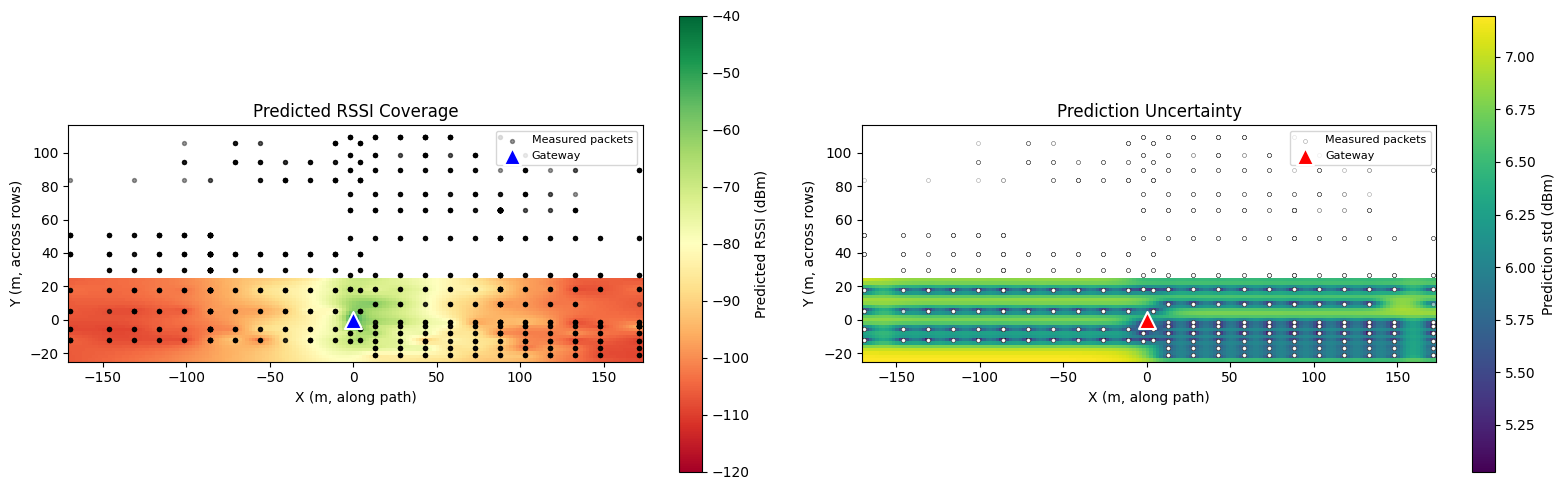

In [67]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Reshape grid predictions back to 2D for heatmap plotting
rssi_grid = grid_df['rssi_pred'].values.reshape(xx.shape)
std_grid = grid_df['rssi_std'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel 1: Predicted RSSI coverage ---
im1 = axes[0].pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto',
                           vmin=-120, vmax=-40)  # typical LoRa RSSI range
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted RSSI (dBm)')

# Overlay measured points for reference
axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=8, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)

axes[0].set_xlabel('X (m, along path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted RSSI Coverage')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: Prediction uncertainty ---
im2 = axes[1].pcolormesh(xx, yy, std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Prediction std (dBm)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=8, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)

axes[1].set_xlabel('X (m, along path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('Prediction Uncertainty')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
grid_df['rssi_std'] = np.sqrt(grid_df['gpr_std']**2 + sigma_n_dbm**2)

print(grid_df['gpr_std'].describe())

count    4300.000000
mean        4.982925
std         0.295404
min         4.155700
25%         4.704575
50%         5.166341
75%         5.214820
max         5.218619
Name: gpr_std, dtype: float64


In [ ]:
# Check gpr_std at a location essentially on top of a real training point
test_point = X_gpr_scaled[0:1]  # first training point, already scaled
_, std_at_known = gpr.predict(test_point, return_std=True)
print(f'Predictive std AT a training point: {std_at_known[0]:.4f}')

# Compare to a point far from all data (edge of your grid)
far_point = scaler.transform([[170, 24]])
_, std_far = gpr.predict(far_point, return_std=True)
print(f'Predictive std FAR from data     : {std_far[0]:.4f}')

Predictive std AT a training point: 4.0892
Predictive std FAR from data     : 5.2180


In [68]:
import joblib

# Save the fitted GPR, the scaler, and the path-loss coefficients —
# all three are needed together to reproduce predictions later
joblib.dump(gpr, 'gpr_model.pkl')
joblib.dump(scaler, 'coord_scaler.pkl')
joblib.dump(coeffs_full, 'pathloss_coeffs.pkl')

print('Saved: gpr_model.pkl, coord_scaler.pkl, pathloss_coeffs.pkl')

Saved: gpr_model.pkl, coord_scaler.pkl, pathloss_coeffs.pkl


In [ ]:
# TO RELOAD 
gpr = joblib.load('gpr_model.pkl')
scaler = joblib.load('coord_scaler.pkl')
coeffs_full = joblib.load('pathloss_coeffs.pkl')


In [69]:
cv_rmse_mean = np.mean(cv_fold_rmse)  # only if cv_fold_rmse is still in memory
cv_rmse_std = np.std(cv_fold_rmse)
joblib.dump(cv_fold_rmse, 'cv_fold_rmse.pkl')  # save it now before anything else happens

NameError: name 'cv_fold_rmse' is not defined

In [70]:
# check how close the y-length-scale landed to the old bound
print(gpr.kernel_.k1.k2.length_scale)  # look at the second value specifically

[0.19846696 0.13208488]


In [71]:
import joblib
import os

# --- Load if already saved, otherwise fit fresh ---
if os.path.exists('gpr_model.pkl'):
    print('Loading saved model...')
    gpr = joblib.load('gpr_model.pkl')
else:
    print('No saved model found — fitting fresh...')
    kernel_final = (
        ConstantKernel(1.0, (0.1, 10.0)) *
        Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5) +
        WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel_final,
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gpr.fit(X_gpr_scaled, y_gpr)
    joblib.dump(gpr, 'gpr_model.pkl')
    joblib.dump(scaler, 'coord_scaler.pkl')
    joblib.dump(coeffs_full, 'pathloss_coeffs.pkl')
    print('Saved: gpr_model.pkl, coord_scaler.pkl, pathloss_coeffs.pkl')

print('=== GPR Fitted Kernel (nu=0.5) ===')
print(f'  {gpr.kernel_}')
print()

# Extract fitted hyperparameters
k_amplitude = gpr.kernel_.k1.k1.constant_value ** 0.5
k_length    = np.atleast_1d(gpr.kernel_.k1.k2.length_scale)
k_noise     = gpr.kernel_.k2.noise_level ** 0.5

l_scaled_x, l_scaled_y = k_length[0], k_length[1]
l_meters_x = l_scaled_x * scaler.scale_[0]
l_meters_y = l_scaled_y * scaler.scale_[1]

y_std = y_gpr.std()
k_amplitude_dbm = k_amplitude * y_std
k_noise_dbm = k_noise * y_std

print(f'  σ_f (amplitude)       : {k_amplitude_dbm:.3f} dBm   (raw fit value: {k_amplitude:.3f}, standardized)')
print(f'  l_x (scaled units)    : {l_scaled_x:.3f}   ≈ {l_meters_x:.2f} m (along path)')
print(f'  l_y (scaled units)    : {l_scaled_y:.3f}   ≈ {l_meters_y:.2f} m (across rows)')
print(f'  σ_n (noise std dev)   : {k_noise_dbm:.3f} dBm   (raw fit value: {k_noise:.3f}, standardized)')
print()

y_pred_train, y_std_train = gpr.predict(X_gpr_scaled, return_std=True)
rmse_gpr_train = np.sqrt(mean_squared_error(y_gpr, y_pred_train))

# Real CV numbers from your grouped 5-fold sweep (nu=0.5 winner)
cv_rmse_mean = 5.724
cv_rmse_std = 0.785

print('Interpretation:')
print(f'  Spatial correlation extends ~{l_meters_x:.1f} m along the walking path')
print(f'  and ~{l_meters_y:.1f} m across rows.')
print(f'  Packet-to-packet noise std: {k_noise_dbm:.2f} dBm')
print()
print(f'  Train RMSE (optimistic)   : {rmse_gpr_train:.3f} dBm')
print(f'  CV RMSE (honest estimate) : {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm  (from grouped CV)')
print(f'  Path-loss-only RMSE       : {rmse_full:.2f} dBm  (baseline, no GPR)')
print()
print(f'  Residual std before GPR   : {y_gpr.std():.3f} dBm')
print(f'  Residual std after GPR    : {(y_gpr - y_pred_train).std():.3f} dBm')

Loading saved model...
=== GPR Fitted Kernel (nu=0.5) ===
  0.852**2 * Matern(length_scale=[0.198, 0.132], nu=0.5) + WhiteKernel(noise_level=0.293)

  σ_f (amplitude)       : 5.367 dBm   (raw fit value: 0.852, standardized)
  l_x (scaled units)    : 0.198   ≈ 17.90 m (along path)
  l_y (scaled units)    : 0.132   ≈ 4.87 m (across rows)
  σ_n (noise std dev)   : 3.410 dBm   (raw fit value: 0.541, standardized)

Interpretation:
  Spatial correlation extends ~17.9 m along the walking path
  and ~4.9 m across rows.
  Packet-to-packet noise std: 3.41 dBm

  Train RMSE (optimistic)   : 3.179 dBm
  CV RMSE (honest estimate) : 5.724 ± 0.785 dBm  (from grouped CV)
  Path-loss-only RMSE       : 6.30 dBm  (baseline, no GPR)

  Residual std before GPR   : 6.299 dBm
  Residual std after GPR    : 3.179 dBm


Model                           RMSE (dBm)    MAE (dBm)     R²      
--------------------------------------------------------------------
Path-Loss Only                  6.299         4.806         0.746   
Path-Loss + GPR (train)         3.179         2.177         0.935   
Path-Loss + GPR (CV, honest)    5.724         —             —       

Improvement (honest, CV-based): 0.575 dBm (9.1%)


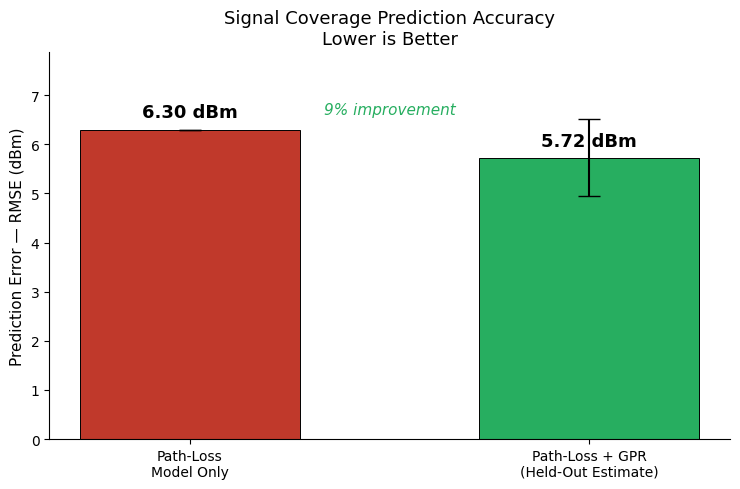

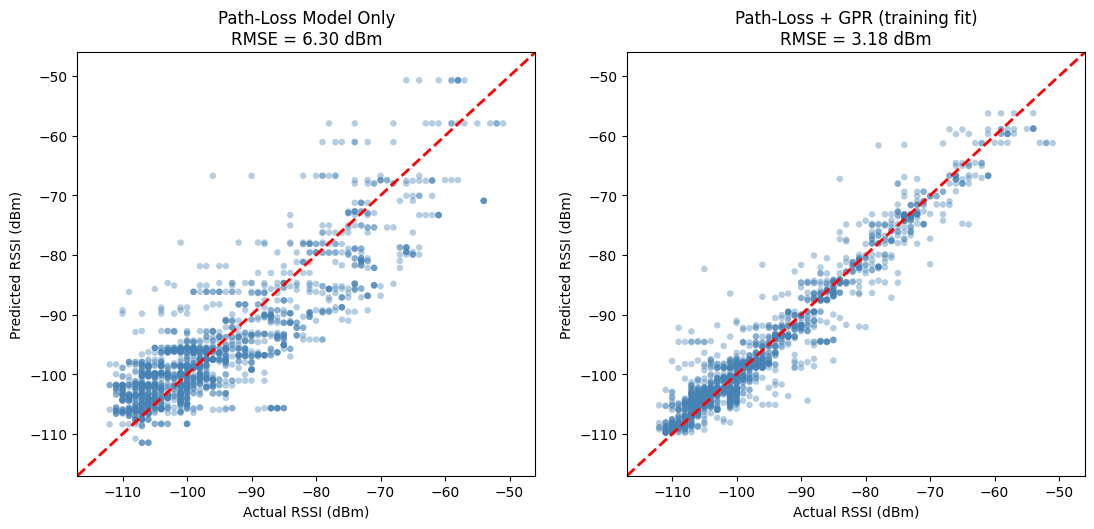

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 1. Clean metrics summary ===
pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values
gpr_combined_rssi = pl_pred_rssi + y_pred_train   # training-set combined prediction

pl_rmse = rmse_full
pl_mae = mean_absolute_error(actual_rssi, pl_pred_rssi)
pl_r2 = r2_score(actual_rssi, pl_pred_rssi)

gpr_train_rmse = np.sqrt(mean_squared_error(actual_rssi, gpr_combined_rssi))
gpr_train_mae = mean_absolute_error(actual_rssi, gpr_combined_rssi)
gpr_train_r2 = r2_score(actual_rssi, gpr_combined_rssi)

print(f"{'Model':<32}{'RMSE (dBm)':<14}{'MAE (dBm)':<14}{'R²':<8}")
print('-' * 68)
print(f"{'Path-Loss Only':<32}{pl_rmse:<14.3f}{pl_mae:<14.3f}{pl_r2:<8.3f}")
print(f"{'Path-Loss + GPR (train)':<32}{gpr_train_rmse:<14.3f}{gpr_train_mae:<14.3f}{gpr_train_r2:<8.3f}")
print(f"{'Path-Loss + GPR (CV, honest)':<32}{cv_rmse_mean:<14.3f}{'—':<14}{'—':<8}")
print()
print(f"Improvement (honest, CV-based): {pl_rmse - cv_rmse_mean:.3f} dBm "
      f"({100*(pl_rmse - cv_rmse_mean)/pl_rmse:.1f}%)")

# === 2. Headline bar chart ===
fig, ax = plt.subplots(figsize=(7.5, 5))

labels = ['Path-Loss\nModel Only', 'Path-Loss + GPR\n(Held-Out Estimate)']
values = [pl_rmse, cv_rmse_mean]
errors = [0, cv_rmse_std]
colors = ['#c0392b', '#27ae60']

bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors,
               edgecolor='black', linewidth=0.7, width=0.55)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.25, f'{val:.2f} dBm',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Prediction Error — RMSE (dBm)', fontsize=11)
ax.set_title('Signal Coverage Prediction Accuracy\nLower is Better', fontsize=13)
ax.set_ylim(0, max(values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

improvement_pct = 100 * (pl_rmse - cv_rmse_mean) / pl_rmse
ax.annotate(f'{improvement_pct:.0f}% improvement',
            xy=(0.5, max(values) * 1.05), ha='center', fontsize=11,
            style='italic', color='#27ae60')

plt.tight_layout()
plt.savefig('presentation_rmse_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# === 3. Predicted vs. actual scatter, side by side ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (pred, title, rmse_val) in zip(
    axes,
    [(pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
     (gpr_combined_rssi, 'Path-Loss + GPR (training fit)', gpr_train_rmse)]
):
    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')

In [73]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Check if you already have pooled CV predictions saved; otherwise regenerate
# for nu=0.5 only (single kernel, ~1/4 the cost of the original 4-nu sweep)

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

# Track predictions AND their original positional index, so we can map
# back to pl_pred for the correct row and reconstruct full RSSI scale
cv_pred_residual = np.full(len(y_gpr), np.nan)

kernel_cv = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
)

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_cv,
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
    cv_pred_residual[test_idx] = gp_cv.predict(X_gpr_scaled[test_idx])

# Sanity check — every point should have been predicted exactly once
assert not np.isnan(cv_pred_residual).any(), "Some points were never in a test fold!"

# Reconstruct RSSI-scale predictions using the SAME positional alignment as pl_pred_rssi
cv_pred_rssi = pl_pred_rssi + cv_pred_residual
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi))
print(f'CV RMSE (reconstructed, RSSI scale): {cv_rmse_check:.3f} dBm')
print(f'(Should roughly match your earlier residual-scale CV RMSE: {cv_rmse_mean:.3f} dBm)')

CV RMSE (reconstructed, RSSI scale): 5.776 dBm
(Should roughly match your earlier residual-scale CV RMSE: 5.724 dBm)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


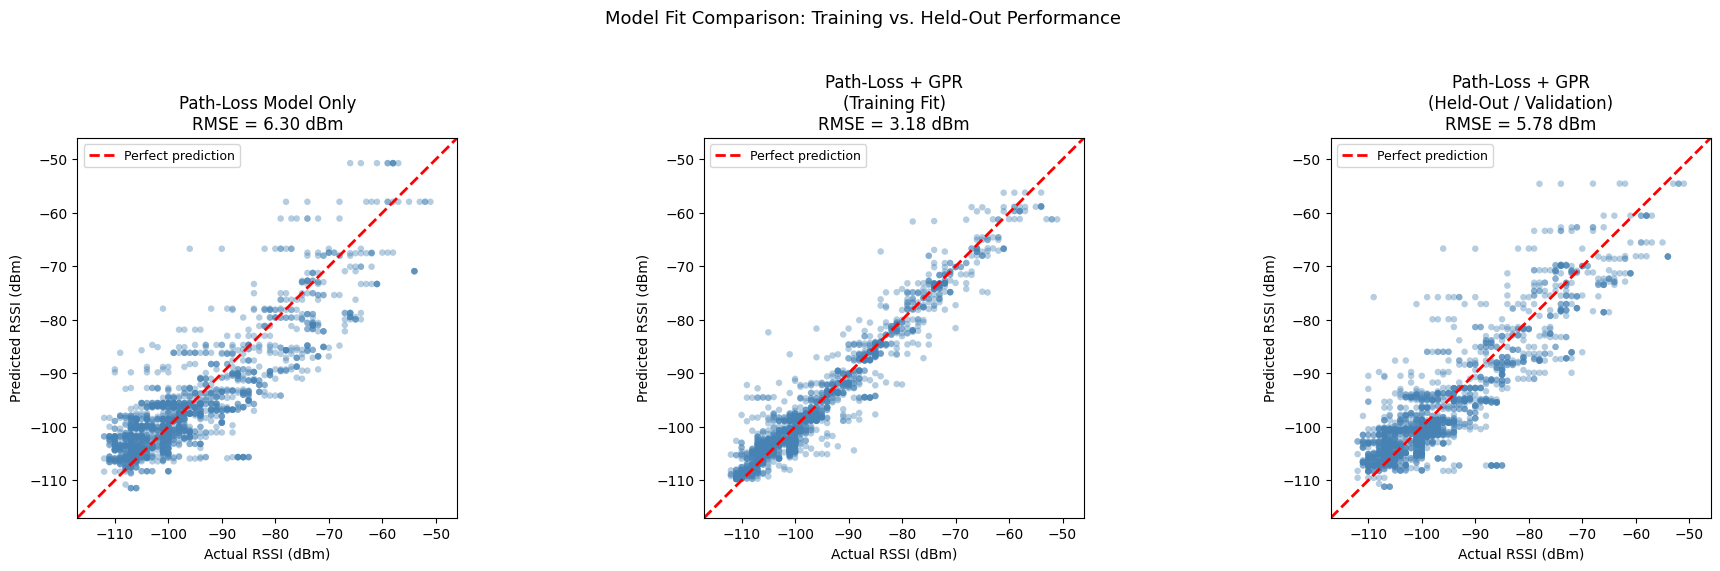

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (gpr_combined_rssi, 'Path-Loss + GPR\n(Training Fit)', gpr_train_rmse),
    (cv_pred_rssi, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Model Fit Comparison: Training vs. Held-Out Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('presentation_scatter_3panel.png', dpi=200, bbox_inches='tight')
plt.show()

In [75]:
import joblib

# Save CV predictions and the CV kernel definition — cheap insurance
joblib.dump(cv_pred_residual, 'cv_pred_residual.pkl')
joblib.dump(cv_pred_rssi, 'cv_pred_rssi.pkl')
joblib.dump(cv_rmse_check, 'cv_rmse_check.pkl')
print('CV artifacts saved.')

CV artifacts saved.


In [76]:
import numpy as np
import pandas as pd

x_min, x_max = -165.3, 158.7
y_min, y_max = -92.4, 198.0

grid_res = 2.0  # meters; lower to 1.0 for finer detail if plotting time allows
x_grid = np.arange(x_min, x_max + grid_res, grid_res)
y_grid = np.arange(y_min, y_max + grid_res, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel()})
print(f'Prediction grid: {len(grid_df)} points ({len(x_grid)} x {len(y_grid)})')

# --- Path-loss prediction ---
grid_df['distance'] = np.sqrt(grid_df['x_m']**2 + grid_df['y_m']**2)
grid_df.loc[grid_df['distance'] == 0, 'distance'] = 0.01  # avoid log10(0)

# Row spacing is 1.1m per your correction — recompute row_crossings consistently
grid_df['row_crossings'] = (grid_df['y_m'].abs() / 1.1).round().astype(int)

log_d_grid = np.log10(grid_df['distance'].values)
crossings_grid = grid_df['row_crossings'].values
X_pl_grid = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['pl_pred'] = X_pl_grid @ coeffs_full

# --- GPR prediction (using the saved final model) ---
X_grid_coords = grid_df[['x_m', 'y_m']].values
X_grid_scaled = scaler.transform(X_grid_coords)  # reuse training scaler — never refit

gpr_mean, gpr_std = gpr.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred'] = gpr_mean
grid_df['gpr_std'] = gpr_std  # already in dBm — no rescaling needed (verified earlier)

grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

sigma_n_dbm = k_noise_dbm
grid_df['rssi_std'] = np.sqrt(grid_df['gpr_std']**2 + sigma_n_dbm**2)

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'gpr_std', 'rssi_std']].describe())

Prediction grid: 23961 points (163 x 147)
                x_m           y_m       pl_pred  gpr_residual_pred  \
count  23961.000000  23961.000000  23961.000000       23961.000000   
mean      -3.300000     53.600000   -103.148808          -0.016409   
std       94.108287     84.870297     10.057980           2.242742   
min     -165.300000    -92.400000   -120.801784         -14.386396   
25%      -85.300000    -20.400000   -110.275970          -0.239153   
50%       -3.300000     53.600000   -104.233479          -0.000003   
75%       78.700000    127.600000    -97.889230           0.023325   
max      158.700000    199.600000    -26.080562          11.683972   

          rssi_pred       gpr_std      rssi_std  
count  23961.000000  23961.000000  23961.000000  
mean    -103.165217      5.973837      6.884825  
std       10.430012      0.564906      0.480411  
min     -120.801784      3.651749      4.996102  
25%     -110.176359      5.693440      6.636341  
50%     -104.950439      6.

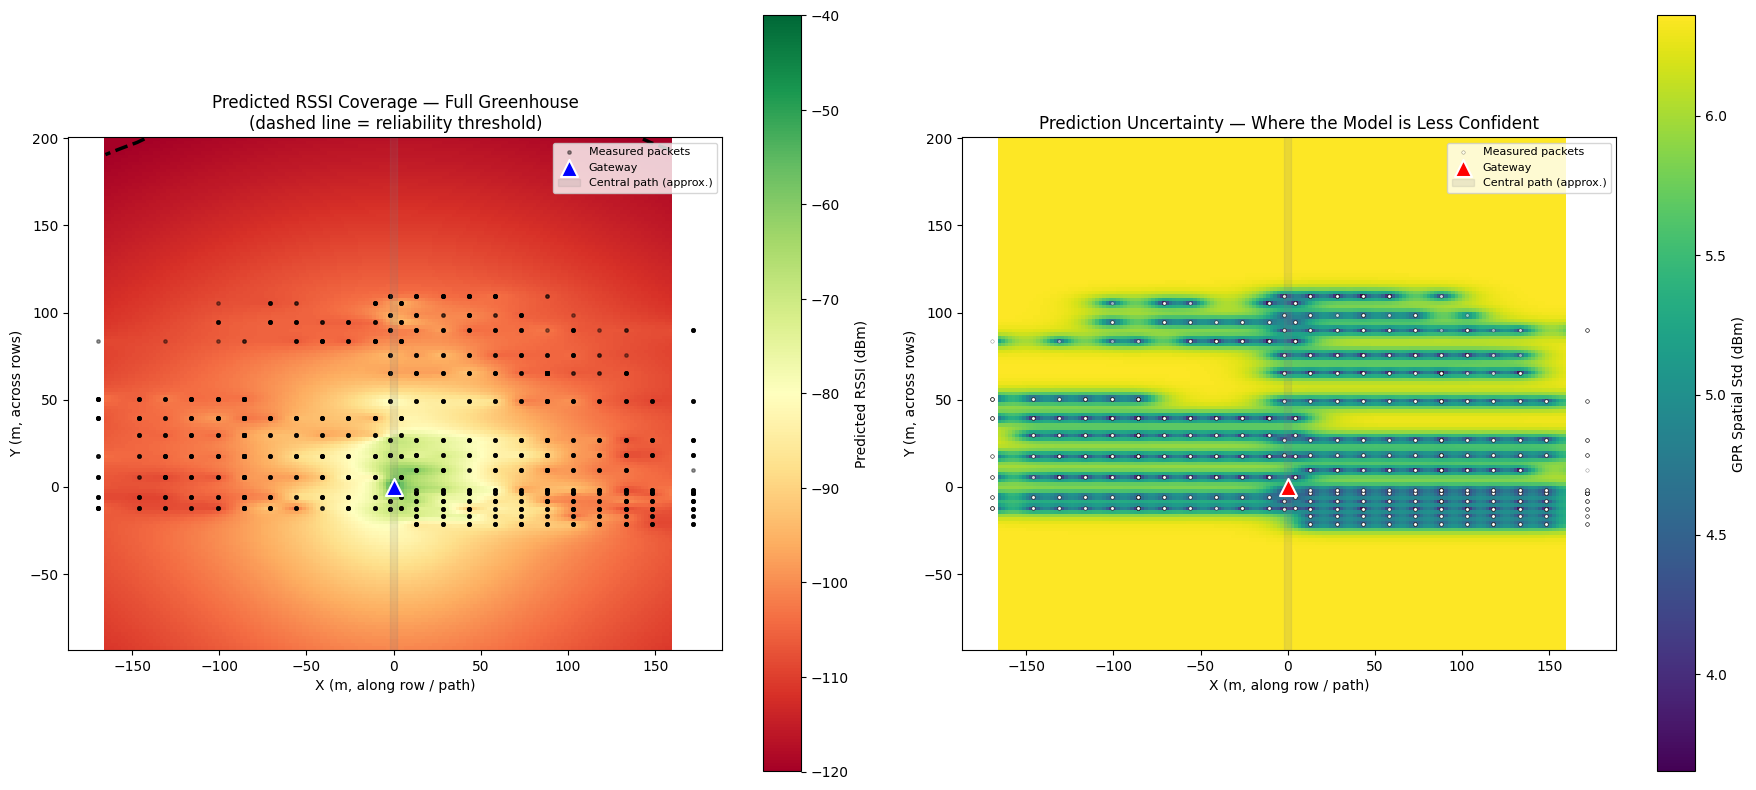

In [82]:
import matplotlib.pyplot as plt

rssi_grid = grid_df['rssi_pred'].values.reshape(xx.shape)
std_grid = grid_df['gpr_std'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_dbm = -120  # adjust to your target SF's sensitivity + desired margin

# --- Panel 1: Predicted RSSI coverage ---
im1 = axes[0].pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto',
                           vmin=-120, vmax=-40)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted RSSI (dBm)')

contour1 = axes[0].contour(xx, yy, rssi_grid, levels=[threshold_dbm],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_dbm} dBm', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted RSSI Coverage — Full Greenhouse\n(dashed line = reliability threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: Prediction uncertainty (unchanged, contour not meaningful here) ---
im2 = axes[1].pcolormesh(xx, yy, std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dBm)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()

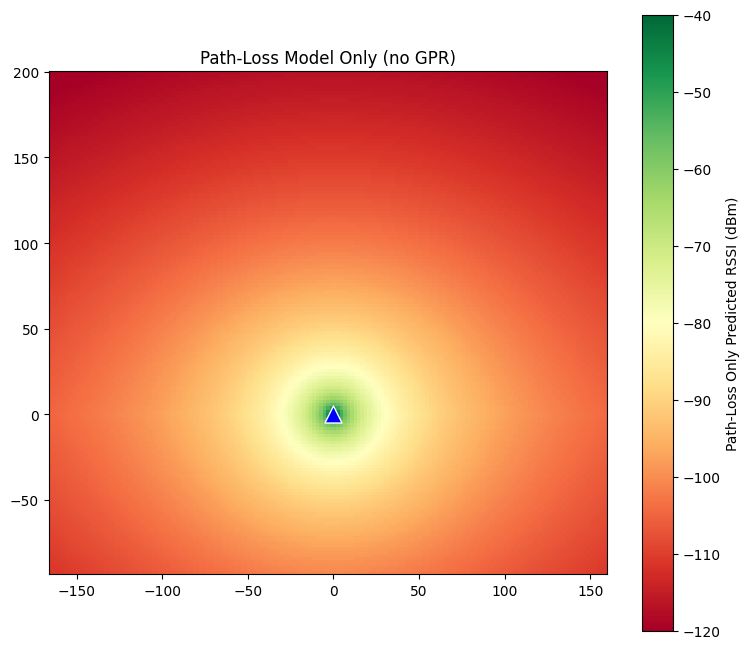

row_crossings range in grid: 0 to 181
beta (row penalty): -0.051 dBm/crossing
Max row penalty at grid edge: -9.2 dBm


In [78]:
pl_only_grid = grid_df['pl_pred'].values.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(xx, yy, pl_only_grid, cmap='RdYlGn', shading='auto', vmin=-120, vmax=-40)
plt.colorbar(im, ax=ax, label='Path-Loss Only Predicted RSSI (dBm)')
ax.scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white', zorder=5)
ax.set_title('Path-Loss Model Only (no GPR)')
ax.set_aspect('equal')
plt.show()

print(f"row_crossings range in grid: {grid_df['row_crossings'].min()} to {grid_df['row_crossings'].max()}")
print(f"beta (row penalty): {beta:.3f} dBm/crossing")
print(f"Max row penalty at grid edge: {beta * grid_df['row_crossings'].max():.1f} dBm")

In [80]:
far_points = valid[valid['distance'] > 130]
print(f'Packets beyond 130m: {len(far_points)}')
print(far_points[['x_m', 'y_m', 'distance', 'rssi']].sort_values('distance', ascending=False).head(15))

Packets beyond 130m: 371
        x_m   y_m    distance   rssi
1811  171.5  89.8  193.587939 -106.0
1815  171.5  89.8  193.587939 -106.0
1814  171.5  89.8  193.587939 -107.0
1813  171.5  89.8  193.587939 -107.0
1812  171.5  89.8  193.587939 -107.0
1810  171.5  89.8  193.587939 -106.0
1241 -169.5  83.6  188.995264 -108.0
997   171.5  49.1  178.390190 -112.0
998   171.5  49.1  178.390190 -108.0
999   171.5  49.1  178.390190 -107.0
1000  171.5  49.1  178.390190 -109.0
1001  171.5  49.1  178.390190 -110.0
1480 -169.5  50.6  176.891520 -103.0
1479 -169.5  50.6  176.891520 -105.0
1478 -169.5  50.6  176.891520 -105.0


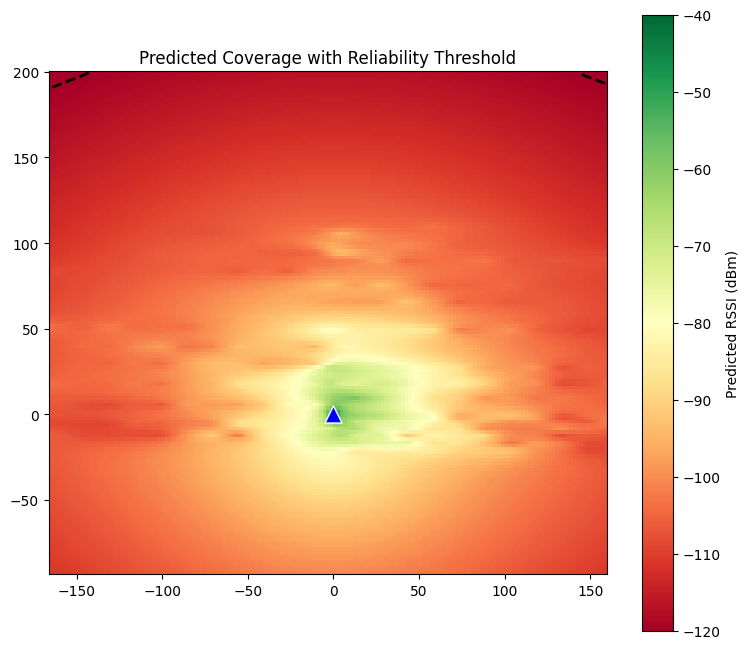

In [81]:
# Add a coverage threshold contour to the RSSI heatmap
threshold_dbm = -120  # adjust to your actual SF's sensitivity + desired margin

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto', vmin=-120, vmax=-40)
plt.colorbar(im, ax=ax, label='Predicted RSSI (dBm)')

contour = ax.contour(xx, yy, rssi_grid, levels=[threshold_dbm], colors='black', linewidths=2)
ax.clabel(contour, fmt=f'{threshold_dbm} dBm threshold')

ax.scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white', zorder=5)
ax.set_title('Predicted Coverage with Reliability Threshold')
ax.set_aspect('equal')
plt.show()